# 📊 Football Visualizations using `mplsoccer`
This notebook demonstrates how to create Pass Map

In [1]:
# Import libraries
import pandas as pd
import matplotlib
from mplsoccer import Pitch, VerticalPitch
import matplotlib.pyplot as plt

In [2]:
# Read CSV file
df = pd.read_csv('barca_valladolid.csv')
df.head()

,id,eventId,minute,second,teamId,x,y,period,type,outcome,playerId,endX,endY
0,2248226915,2,0,0.0,Barcelona,0.0,0.0,1,Start,Successful,NaN,NaN,NaN
1,2248226919,2,0,0.0,Valladolid,0.0,0.0,1,Start,Successful,NaN,NaN,NaN
2,2248226929,3,0,1.0,Barcelona,50.0,50.0,1,Pass,Successful,9.0,43.9,46.9
3,2248226941,4,0,2.0,Barcelona,43.8,46.9,1,Pass,Successful,8.0,36.4,56.0
4,2248226951,5,0,4.0,Barcelona,36.6,56.6,1,Pass,Successful,21.0,28.5,73.8


# Team Pass Map

In [3]:
dfPass = df[(df['type'] == 'Pass') & (df['outcome'] == 'Successful')]

In [5]:
dfBarcaPass = dfPass[dfPass['teamId'] == 'Barcelona']

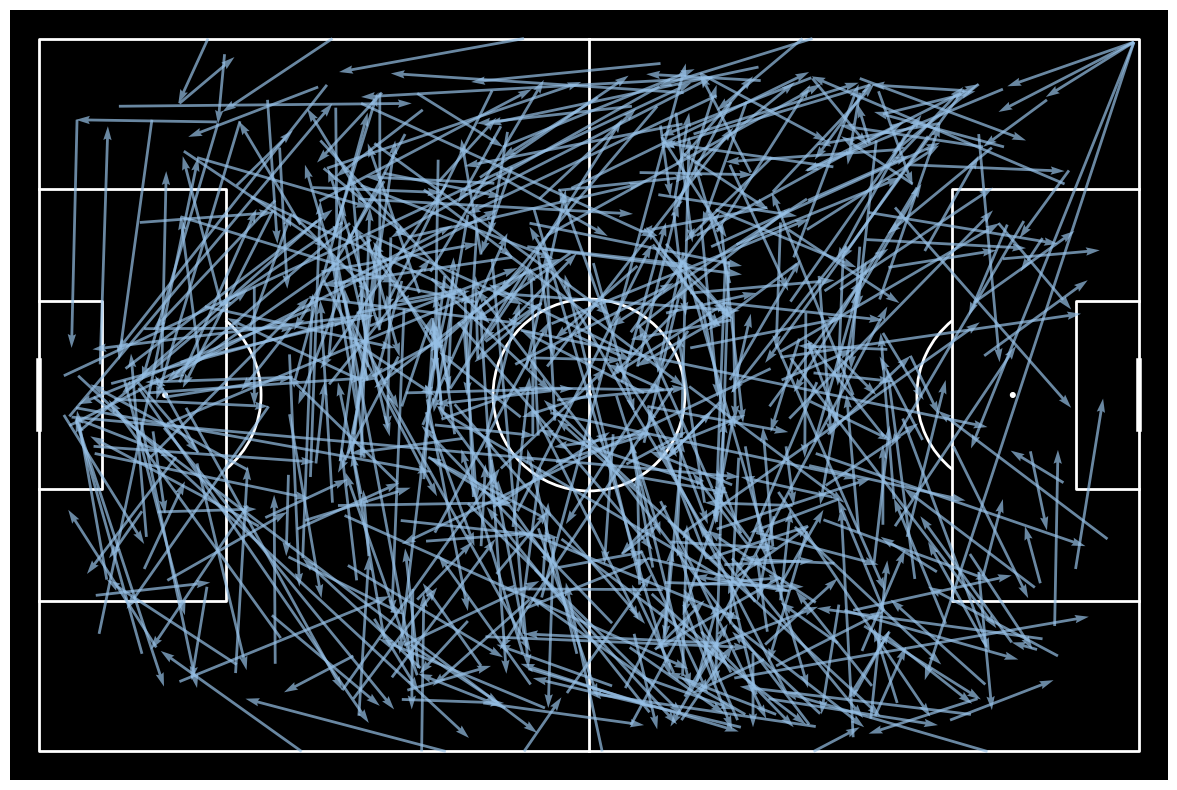

In [8]:
pitch = Pitch(pitch_type='opta', pitch_color='black', 
                      line_color='white')
fig,ax = pitch.draw(figsize=(14, 8))
pitch.arrows(dfBarcaPass['x'], dfBarcaPass['y'],
             dfBarcaPass['endX'], dfBarcaPass['endY'], 
             color='#97c1e7', alpha=.7,
             width=2, ax=ax)
plt.show()


# Player Pass Map

In [9]:
# Read CSV file
df1 = pd.read_csv('messibetis.csv')
df1.head()

,player,minute,second,x,y,type,outcome,endX,endY
0,messi,45,0,50,50,Pass,Successful,40,43
1,messi,45,25,63,48,Pass,Successful,75,83
2,messi,46,4,74,58,Pass,Successful,71,65
3,messi,46,7,76,68,Pass,Successful,95,78
4,messi,46,55,100,1,Pass,Unsuccessful,96,38


In [10]:
dfMessiPass = df1[(df1['outcome'] == 'Successful') & (df1['type'] == 'Pass')]

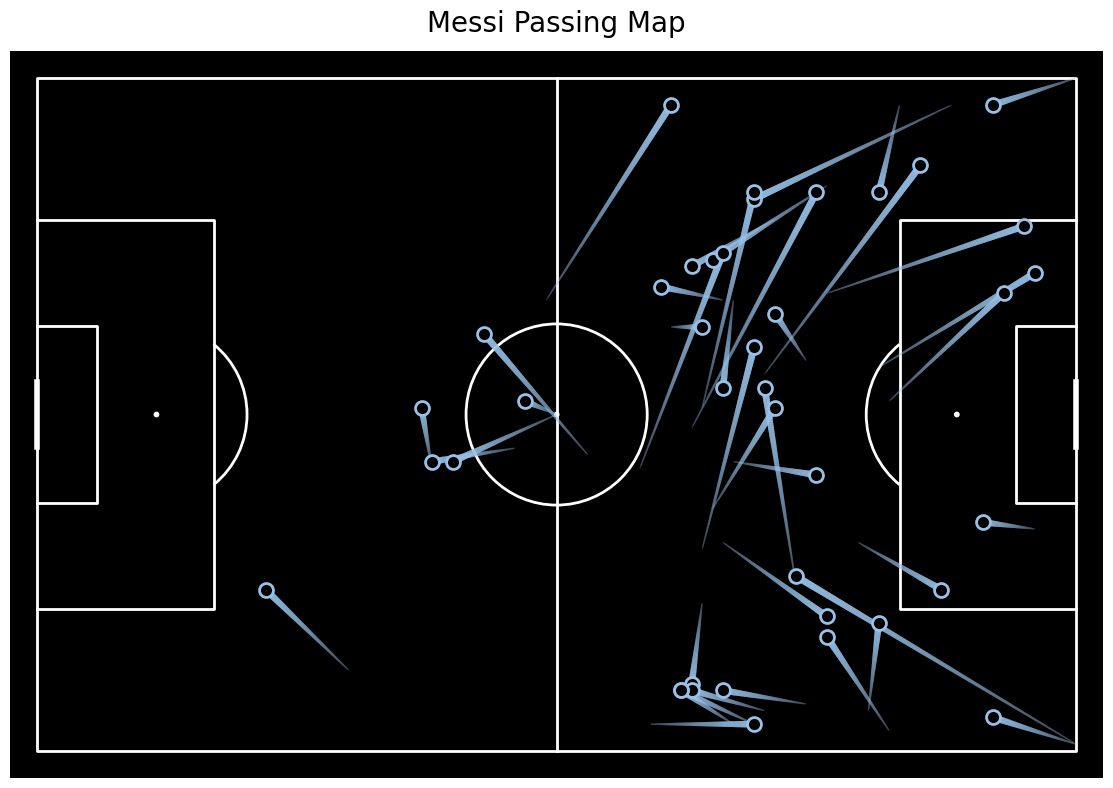

In [ ]:
pitch = Pitch(pitch_type='opta', pitch_color='black', 
                      line_color='white', line_zorder=1)
fig,ax = pitch.draw(figsize=(14, 8))
pitch.lines(dfMessiPass['x'], dfMessiPass['y'],
             dfMessiPass['endX'], dfMessiPass['endY'], 
             color='#97c1e7', comet=True, 
             transparent=True, alpha_start=0.2,alpha_end=0.8,
             zorder=2,
             ax=ax)
fig.suptitle('Messi Passing Map', color='black', fontsize=20, fontweight='bold')
pitch.scatter(dfMessiPass['endX'], dfMessiPass['endY'],
              color='black', edgecolor='#97c1e7', ax=ax,
              s=100, lw=2, zorder=2)
plt.show()
